In [2]:
# Instalar Bibliotecas (rodar no Windows terminal/powershell)
# pip install yfinance numpy matplotlib plotly-express seaborn radian 

# Importando bases
import radian as rd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import yfinance as yf

In [3]:
##################
### Introdução ###
##################

# Importando um ativo
petro = yf.download("PETR4.SA", start='2015-01-01')
petro

# Open: O preço de abertura nas datas especificadas
# High: O preço da alta nas datas especificadas
# Low: O preço da baixa nas datas especificadas
# Close: O preço de fechamento nas datas especificadas
# Volume: O volume nas datas especificadas
# Adj Close: O preço de fechamento ajustado depois de aplicar distribuições de dividendos ou divisão da ação.

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,9.990000,9.990000,9.350000,9.360000,3.412899,49559500
2015-01-05,9.140000,9.190000,8.530000,8.560000,3.121199,78385100
2015-01-06,8.710000,8.830000,8.040000,8.280000,3.019103,84723300
2015-01-07,8.560000,8.730000,8.360000,8.670000,3.161308,85531000
2015-01-08,8.790000,9.390000,8.740000,9.230000,3.365498,83306300
...,...,...,...,...,...,...
2024-02-08,42.299999,42.450001,41.860001,41.860001,41.860001,25589100
2024-02-09,42.139999,42.330002,41.299999,41.299999,41.299999,30388000
2024-02-14,41.099998,41.400002,40.860001,40.990002,40.990002,18315300


In [4]:
petro.info()
petro.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2268 entries, 2015-01-02 to 2024-02-16
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2268 non-null   float64
 1   High       2268 non-null   float64
 2   Low        2268 non-null   float64
 3   Close      2268 non-null   float64
 4   Adj Close  2268 non-null   float64
 5   Volume     2268 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 124.0 KB


,Open,High,Low,Close,Adj Close,Volume
count,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000,2.268000e+03
mean,21.698254,22.032826,21.350529,21.687747,11.087182,6.213777e+07
std,8.391975,8.480344,8.313690,8.407105,8.247377,3.328789e+07
min,4.200000,4.270000,4.120000,4.200000,1.531429,0.000000e+00
25%,14.490000,14.697500,14.177500,14.427500,5.286166,4.092760e+07
50%,23.165000,23.535001,22.804999,23.175000,9.118575,5.527355e+07
75%,28.142499,28.455000,27.697500,28.112501,12.315676,7.478450e+07
max,42.299999,42.889999,42.060001,42.689999,42.689999,4.902304e+08


In [5]:
# Importando multiplos ativos 
acoes = ['PETR4.SA', 'VALE3.SA', 'WEGE3.SA', 'ITUB4.SA', 'TOTS3.SA', 'BOVA11.SA']

In [6]:
# Criando um vetor de ativos
acoes_vector = pd.DataFrame()
for acao in acoes:
  acoes_vector[acao] = yf.download(acao, start='2015-01-01')['Close']
acoes_vector

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,PETR4.SA,VALE3.SA,WEGE3.SA,ITUB4.SA,TOTS3.SA,BOVA11.SA
Date,,,,,,
2015-01-02,9.360000,21.280001,5.923076,18.639118,11.881510,47.259998
2015-01-05,8.560000,20.959999,5.963461,18.732782,11.516435,46.320000
2015-01-06,8.280000,21.799999,5.875000,19.035812,10.796243,46.580002
2015-01-07,8.670000,22.600000,5.807692,19.724518,10.719909,48.150002
2015-01-08,9.230000,22.840000,5.905769,20.033056,10.968824,48.509998
...,...,...,...,...,...,...
2024-02-08,41.860001,66.209999,33.799999,33.860001,29.639999,124.510002
2024-02-09,41.299999,65.919998,33.369999,34.290001,30.620001,124.129997
2024-02-14,40.990002,65.720001,33.529999,34.290001,29.990000,123.230003


In [7]:
# Renomeando Vetores
acoes_df = acoes_vector.rename(columns={'PETR4.SA': 'PETR', 'VALE3.SA': 'VALE', 'WEGE3.SA': 'WEGE','ITUB4.SA': 'ITAÚ', 'BOVA11.SA': 'BOVA'})
acoes_df

,PETR,VALE,WEGE,ITAÚ,TOTS3.SA,BOVA
Date,,,,,,
2015-01-02,9.360000,21.280001,5.923076,18.639118,11.881510,47.259998
2015-01-05,8.560000,20.959999,5.963461,18.732782,11.516435,46.320000
2015-01-06,8.280000,21.799999,5.875000,19.035812,10.796243,46.580002
2015-01-07,8.670000,22.600000,5.807692,19.724518,10.719909,48.150002
2015-01-08,9.230000,22.840000,5.905769,20.033056,10.968824,48.509998
...,...,...,...,...,...,...
2024-02-08,41.860001,66.209999,33.799999,33.860001,29.639999,124.510002
2024-02-09,41.299999,65.919998,33.369999,34.290001,30.620001,124.129997
2024-02-14,40.990002,65.720001,33.529999,34.290001,29.990000,123.230003


In [8]:
acoes_df.isnull().sum()
acoes_df.dropna(inplace=True)  
acoes_df.isnull().sum()  

PETR        0
VALE        0
WEGE        0
ITAÚ        0
TOTS3.SA    0
BOVA        0
dtype: int64

<Axes: xlabel='PETR', ylabel='Count'>

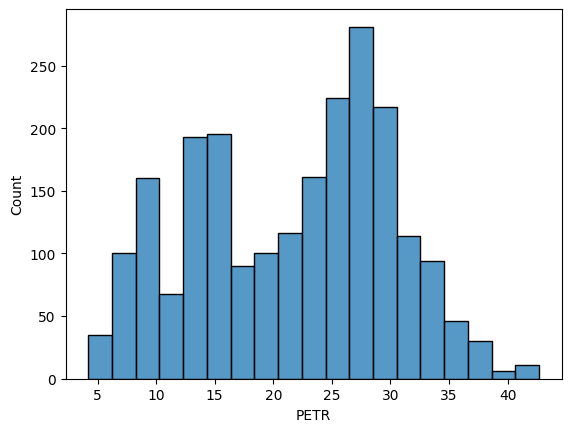

In [17]:
sns.histplot(acoes_df['PETR'])

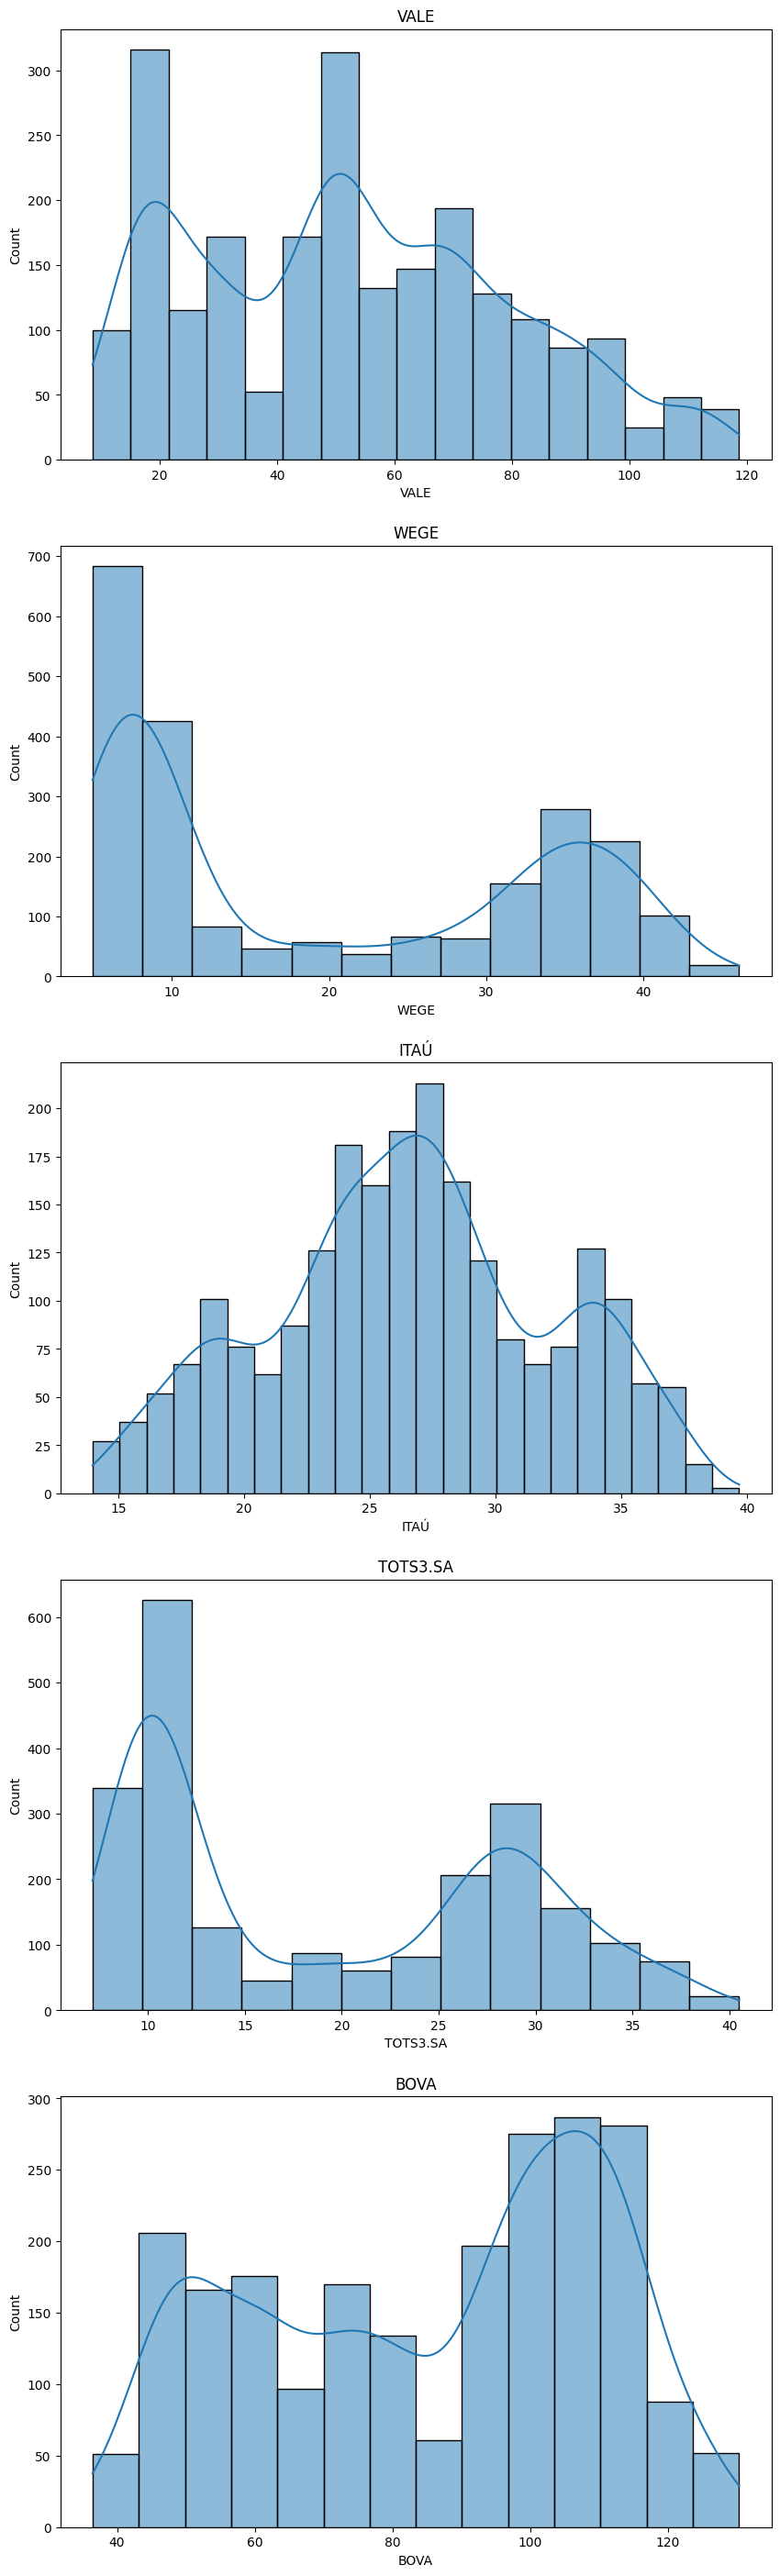

In [33]:
plt.figure(figsize=(10,50))
i = 1
for i in np.arange(1, len(acoes_df.columns)):
  plt.subplot(7, 1, i + 1)
  sns.histplot(acoes_df[acoes_df.columns[i]], kde = True)
  plt.title(acoes_df.columns[i])

<Axes: title={'center': 'Histórico do preço das ações'}, xlabel='Date'>

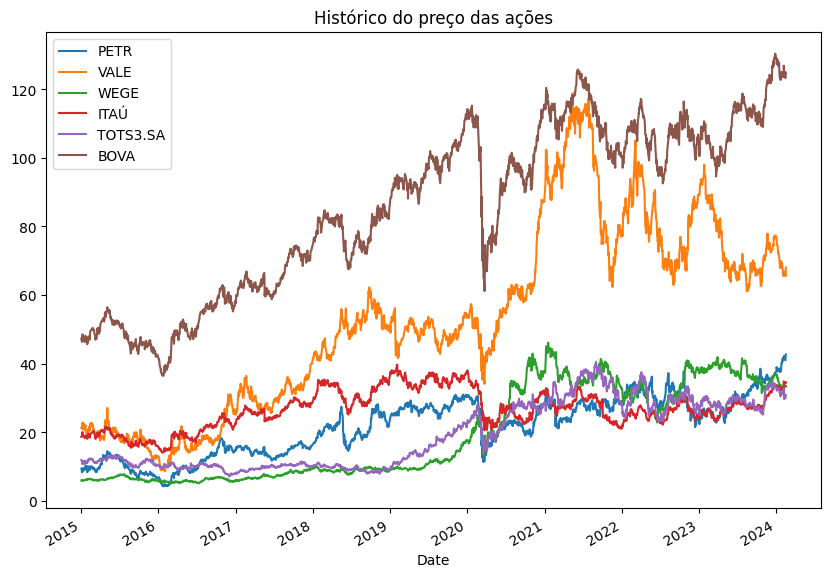

In [57]:
acoes_df.plot(figsize = (10,7), title = 'Histórico do preço das ações')

In [58]:
# Valores Normalizados (divindindo cada preço, pelo preço incial) - quanto multiplicamos nosso capital sobre o valor da data de compra - taxa de crescimento
acoes_df_normalizado = acoes_df.copy()
for i in acoes_df_normalizado.columns[1:]:
  acoes_df_normalizado[i] = acoes_df_normalizado[i] / acoes_df_normalizado[i][0]
acoes_df_normalizado

,PETR,VALE,WEGE,ITAÚ,TOTS3.SA,BOVA
Date,,,,,,
2015-01-02,9.360000,1.000000,1.000000,1.000000,1.000000,1.000000
2015-01-05,8.560000,0.984962,1.006818,1.005025,0.969274,0.980110
2015-01-06,8.280000,1.024436,0.991883,1.021283,0.908659,0.985612
2015-01-07,8.670000,1.062030,0.980520,1.058232,0.902235,1.018832
2015-01-08,9.230000,1.073308,0.997078,1.074786,0.923184,1.026449
...,...,...,...,...,...,...
2024-02-08,41.860001,3.111372,5.706494,1.816610,2.494632,2.634575
2024-02-09,41.299999,3.097744,5.633897,1.839679,2.577114,2.626534
2024-02-14,40.990002,3.088346,5.660910,1.839679,2.524090,2.607491


<Axes: title={'center': 'Histórico do preço das ações - normalizado'}, xlabel='Date'>

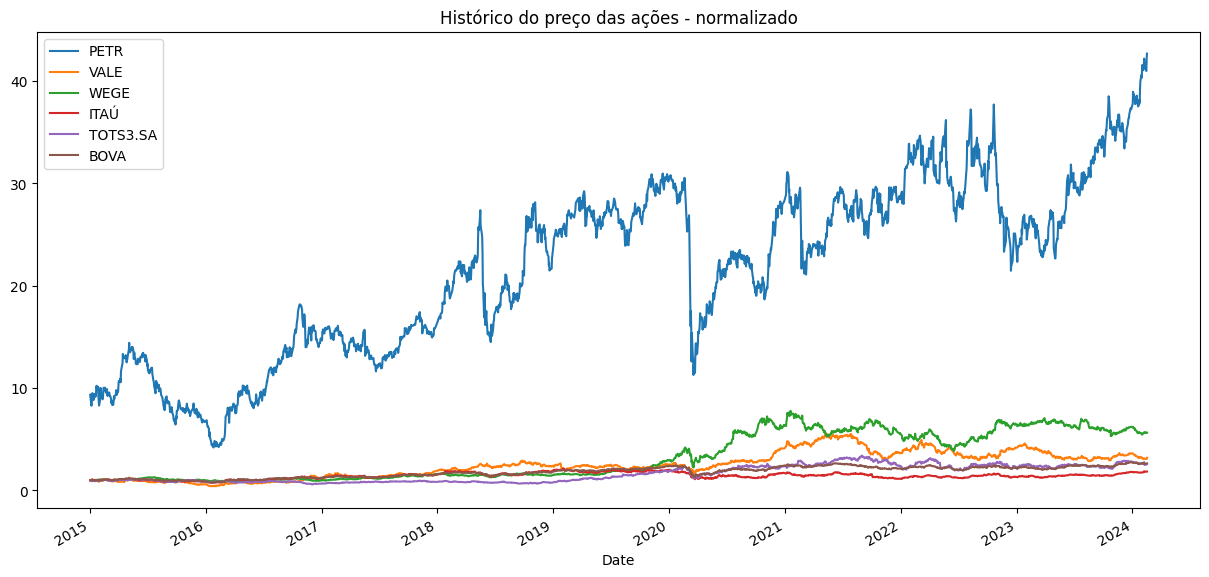

In [60]:
acoes_df_normalizado.plot(figsize = (15,7), title = 'Histórico do preço das ações - normalizado')

In [ ]:
figura = px.line(title = 'Histórico do preço das ações')
for i in acoes_df.columns[1:]:
  figura.add_scatter(x = acoes_df['Date'], y = acoes_df[i], name = i)
figura.show()

In [ ]:
figura = px.line(title = 'Histórico do preço das ações - normalizado')
for i in acoes_df_normalizado.columns[1:]:
  figura.add_scatter(x = acoes_df_normalizado['Date'], y = acoes_df_normalizado[i], name = i)
figura.show()

In [ ]:
########################
### Taxas de retorno ###
########################

len(dataset)
dataset['GOL'][0], dataset['GOL'][len(dataset) - 1]

In [ ]:
# Taxa de Retorno Simples 
((dataset['GOL'][len(dataset) - 1] - dataset['GOL'][0]) / dataset['GOL'][0]) * 100